<a href="https://colab.research.google.com/github/Chaitanya081/DSA0205_Computer-Vision-with-OpenCV/blob/main/CO4_AT1(DSA0205_192424185).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Computing Precision, Recall, and F1-Score for a Viola-Jones Face Detector Output

Saving image.jpg to image.jpg


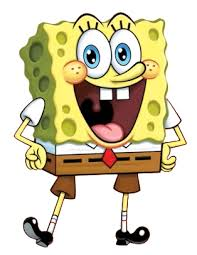

Detected Faces: 0
Precision: 0
Recall: 0.0
F1-Score: 0


In [2]:
import cv2
import numpy as np
import urllib.request
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

if img is None:
    print("Image could not be loaded.")
else:
    model_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
    model_file = "face_detection_yunet_2023mar.onnx"

    urllib.request.urlretrieve(model_url, model_file)

    h, w = img.shape[:2]

    detector = cv2.FaceDetectorYN.create(
        model_file,
        "",
        (w, h),
        0.8,
        0.3,
        5000
    )

    detector.setInputSize((w, h))

    _, faces = detector.detect(img)

    if faces is None:
        faces = []

    predicted = len(faces)

    ground_truth = 1

    true_positive = min(predicted, ground_truth)
    false_positive = max(predicted - ground_truth, 0)
    false_negative = max(ground_truth - predicted, 0)

    precision = true_positive / (true_positive + false_positive) if true_positive + false_positive > 0 else 0

    recall = true_positive / (true_positive + false_negative) if true_positive + false_negative > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    output = img.copy()

    for face in faces:
        x, y, width, height = face[:4].astype(int)

        cv2.rectangle(
            output,
            (x, y),
            (x + width, y + height),
            (0, 255, 0),
            2
        )

    cv2_imshow(output)

    print("Detected Faces:", predicted)
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-Score:", round(f1, 4))

2.YOLO Bounding Box Confidence Scores and Non-Maximum Suppression

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving image1.jpg to image1.jpg

image 1/1 /content/image1.jpg: 640x640 1 skateboard, 446.4ms
Speed: 17.5ms preprocess, 446.4ms inference, 38.2ms postprocess per image at shape (1, 3, 640, 640)
Number of detections: 1
Object: skateboard | Confidence: 0.589


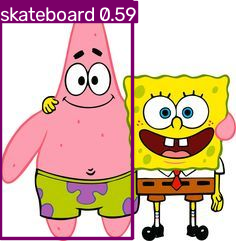

In [3]:
!pip -q install ultralytics

from ultralytics import YOLO
from google.colab import files
import cv2
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

model = YOLO("yolo11n.pt")

results = model(
    filename,
    conf=0.25,
    iou=0.45
)

result = results[0]

print("Number of detections:", len(result.boxes))

for box in result.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    name = model.names[cls]

    print(
        "Object:",
        name,
        "| Confidence:",
        round(conf, 3)
    )

output = result.plot()

cv2_imshow(output)

3.Comparing Viola-Jones vs Deep-Learning-Based Detector

Saving image1.jpg to image1 (1).jpg

image 1/1 /content/image1 (1).jpg: 640x640 1 skateboard, 218.8ms
Speed: 5.8ms preprocess, 218.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
YuNet Face Detections: 0
YuNet Detection Time: 0.008 seconds
YOLO Detections: 1
YOLO Detection Time: 0.2538 seconds
YuNet Result:


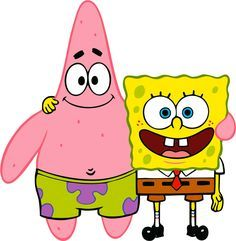

YOLO Result:


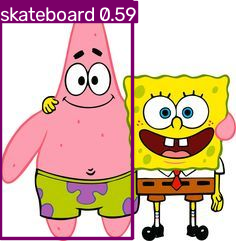

In [4]:
!pip -q install ultralytics

import cv2
import numpy as np
import urllib.request
import time
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

model_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
model_file = "face_detection_yunet_2023mar.onnx"

urllib.request.urlretrieve(model_url, model_file)

h, w = img.shape[:2]

detector = cv2.FaceDetectorYN.create(
    model_file,
    "",
    (w, h),
    0.8,
    0.3,
    5000
)

detector.setInputSize((w, h))

start = time.time()

_, faces = detector.detect(img)

yunet_time = time.time() - start

if faces is None:
    faces = []

yunet_output = img.copy()

for face in faces:
    x, y, width, height = face[:4].astype(int)

    cv2.rectangle(
        yunet_output,
        (x, y),
        (x + width, y + height),
        (0, 255, 0),
        2
    )

model = YOLO("yolo11n.pt")

start = time.time()

results = model(
    filename,
    conf=0.25
)

yolo_time = time.time() - start

yolo_output = results[0].plot()

print("YuNet Face Detections:", len(faces))
print("YuNet Detection Time:", round(yunet_time, 4), "seconds")

print("YOLO Detections:", len(results[0].boxes))
print("YOLO Detection Time:", round(yolo_time, 4), "seconds")

print("YuNet Result:")
cv2_imshow(yunet_output)

print("YOLO Result:")
cv2_imshow(yolo_output)

4.Computing Intersection-over-Union (IoU)

Ground Truth Box: [100, 100, 300, 300]
Predicted Box: [150, 150, 350, 350]
Intersection Area: 22500
Union Area: 57500
IoU: 0.3913


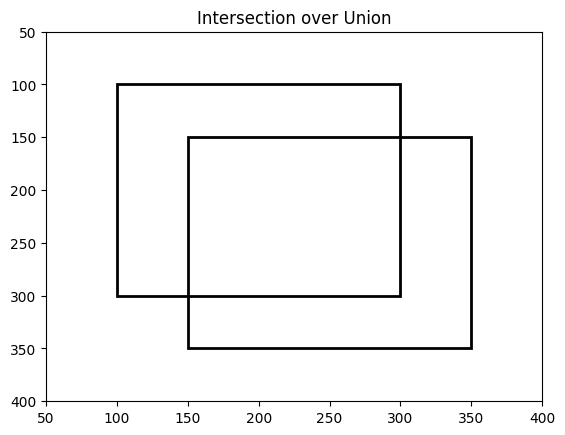

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ground_truth = [100, 100, 300, 300]
prediction = [150, 150, 350, 350]

x1 = max(ground_truth[0], prediction[0])
y1 = max(ground_truth[1], prediction[1])
x2 = min(ground_truth[2], prediction[2])
y2 = min(ground_truth[3], prediction[3])

intersection_width = max(0, x2 - x1)
intersection_height = max(0, y2 - y1)

intersection_area = intersection_width * intersection_height

ground_truth_area = (
    (ground_truth[2] - ground_truth[0]) *
    (ground_truth[3] - ground_truth[1])
)

prediction_area = (
    (prediction[2] - prediction[0]) *
    (prediction[3] - prediction[1])
)

union_area = (
    ground_truth_area +
    prediction_area -
    intersection_area
)

iou = intersection_area / union_area

print("Ground Truth Box:", ground_truth)
print("Predicted Box:", prediction)
print("Intersection Area:", intersection_area)
print("Union Area:", union_area)
print("IoU:", round(iou, 4))

fig, ax = plt.subplots()

rect1 = patches.Rectangle(
    (ground_truth[0], ground_truth[1]),
    ground_truth[2] - ground_truth[0],
    ground_truth[3] - ground_truth[1],
    fill=False,
    linewidth=2
)

rect2 = patches.Rectangle(
    (prediction[0], prediction[1]),
    prediction[2] - prediction[0],
    prediction[3] - prediction[1],
    fill=False,
    linewidth=2
)

ax.add_patch(rect1)
ax.add_patch(rect2)

ax.set_xlim(50, 400)
ax.set_ylim(400, 50)

plt.title("Intersection over Union")
plt.show()

5.Optical Flow Using Lucas-Kanade

Tracked Points: 17


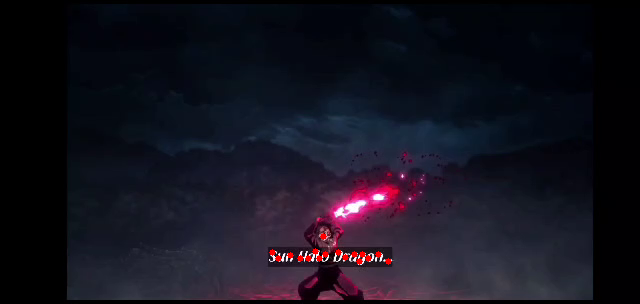

In [7]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

video_name = "video1.mp4"

cap = cv2.VideoCapture(video_name)

ret, old_frame = cap.read()

if not ret:
    print("Video could not be opened.")
else:
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    points = cv2.goodFeaturesToTrack(
        old_gray,
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    ret, new_frame = cap.read()

    if not ret:
        print("Could not read the second frame.")
    else:
        new_gray = cv2.cvtColor(
            new_frame,
            cv2.COLOR_BGR2GRAY
        )

        new_points, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            new_gray,
            points,
            None
        )

        good_old = points[status == 1]
        good_new = new_points[status == 1]

        output = new_frame.copy()

        for old, new in zip(good_old, good_new):
            x1, y1 = old.ravel()
            x2, y2 = new.ravel()

            cv2.arrowedLine(
                output,
                (int(x1), int(y1)),
                (int(x2), int(y2)),
                (0, 255, 0),
                2
            )

            cv2.circle(
                output,
                (int(x2), int(y2)),
                3,
                (0, 0, 255),
                -1
            )

        print("Tracked Points:", len(good_new))

        cv2_imshow(output)

cap.release()

6.Gaussian Mixture Model Background-Foreground Segmentation.

Original Frame:


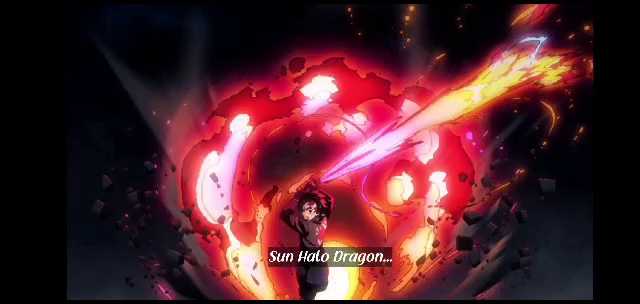

Foreground-Background Segmentation:


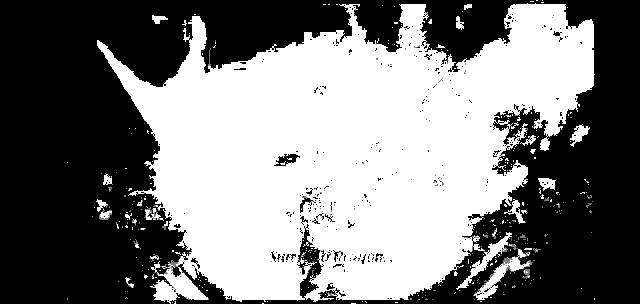

Frames Processed: 50


In [8]:
import cv2
from google.colab.patches import cv2_imshow

video_name = "video1.mp4"

cap = cv2.VideoCapture(video_name)

bg = cv2.createBackgroundSubtractorMOG2(
    history=500,
    varThreshold=16,
    detectShadows=True
)

frame_count = 0
result_frame = None
foreground_mask = None

while frame_count < 50:
    ret, frame = cap.read()

    if not ret:
        break

    foreground_mask = bg.apply(frame)

    if frame_count == 49:
        result_frame = frame

    frame_count += 1

cap.release()

if result_frame is not None:
    print("Original Frame:")
    cv2_imshow(result_frame)

    print("Foreground-Background Segmentation:")
    cv2_imshow(foreground_mask)

    print("Frames Processed:", frame_count)
else:
    print("Video could not be read.")

7.Evaluating GMM Background Subtraction Accuracy Over a Video

Frames Analyzed: 100
Average Foreground Pixels: 68148.23
Maximum Foreground Pixels: 194560
Minimum Foreground Pixels: 0
Average Foreground Percentage: 35.03 %


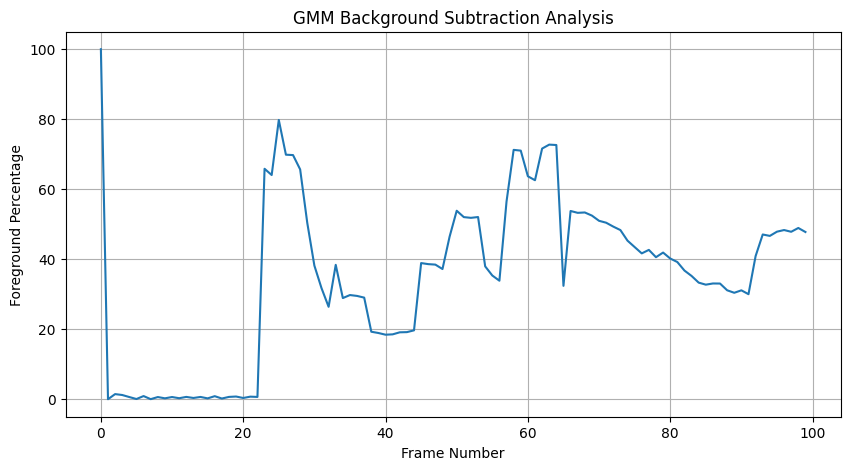

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

video_name = "video1.mp4"

cap = cv2.VideoCapture(video_name)

bg = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=25,
    detectShadows=False
)

frame_numbers = []
foreground_pixels = []
foreground_percentages = []

frame_count = 0

while frame_count < 100:
    ret, frame = cap.read()

    if not ret:
        break

    mask = bg.apply(frame)

    foreground = np.sum(mask == 255)
    total_pixels = mask.shape[0] * mask.shape[1]
    percentage = (foreground / total_pixels) * 100

    frame_numbers.append(frame_count)
    foreground_pixels.append(foreground)
    foreground_percentages.append(percentage)

    frame_count += 1

cap.release()

print("Frames Analyzed:", frame_count)
print("Average Foreground Pixels:", round(np.mean(foreground_pixels), 2))
print("Maximum Foreground Pixels:", np.max(foreground_pixels))
print("Minimum Foreground Pixels:", np.min(foreground_pixels))
print("Average Foreground Percentage:", round(np.mean(foreground_percentages), 2), "%")

plt.figure(figsize=(10, 5))
plt.plot(frame_numbers, foreground_percentages)
plt.xlabel("Frame Number")
plt.ylabel("Foreground Percentage")
plt.title("GMM Background Subtraction Analysis")
plt.grid()
plt.show()

8.Motion Estimation Vectors Between Two Consecutive Frames

Motion Vectors: 17
Average Motion Magnitude: 0.0
Maximum Motion Magnitude: 0.0


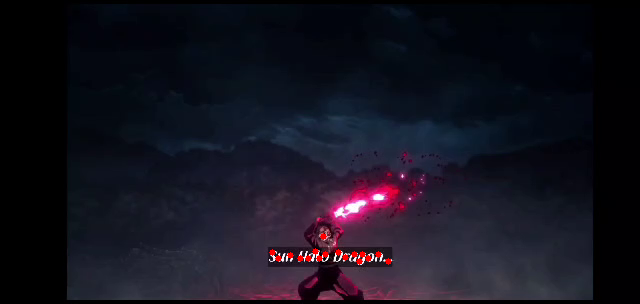

In [10]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

video_name = "video1.mp4"

cap = cv2.VideoCapture(video_name)

ret, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

if not ret or not ret2:
    print("Could not read two consecutive frames.")
else:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    points = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        gray1,
        gray2,
        points,
        None
    )

    good_old = points[status == 1]
    good_new = new_points[status == 1]

    output = frame2.copy()

    magnitudes = []

    for old, new in zip(good_old, good_new):
        x1, y1 = old.ravel()
        x2, y2 = new.ravel()

        dx = x2 - x1
        dy = y2 - y1

        magnitude = np.sqrt(dx**2 + dy**2)
        magnitudes.append(magnitude)

        cv2.arrowedLine(
            output,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            2
        )

        cv2.circle(
            output,
            (int(x2), int(y2)),
            3,
            (0, 0, 255),
            -1
        )

    print("Motion Vectors:", len(good_new))
    print("Average Motion Magnitude:", round(np.mean(magnitudes), 2))
    print("Maximum Motion Magnitude:", round(np.max(magnitudes), 2))

    cv2_imshow(output)

9.Reprojection Error in Structure-from-Motion.

In [11]:
import numpy as np

np.random.seed(42)

points_3d = np.random.rand(20, 3) * 10
points_3d[:, 2] += 5

fx = 800
fy = 800
cx = 320
cy = 240

projected_points = []

for X, Y, Z in points_3d:
    u = fx * X / Z + cx
    v = fy * Y / Z + cy
    projected_points.append([u, v])

projected_points = np.array(projected_points)

observed_points = projected_points + np.random.normal(
    0,
    3,
    projected_points.shape
)

errors = np.linalg.norm(
    observed_points - projected_points,
    axis=1
)

mean_error = np.mean(errors)
max_error = np.max(errors)
min_error = np.min(errors)

print("Number of 3D Points:", len(points_3d))
print("Mean Reprojection Error:", round(mean_error, 4), "pixels")
print("Maximum Reprojection Error:", round(max_error, 4), "pixels")
print("Minimum Reprojection Error:", round(min_error, 4), "pixels")

print("\nFirst 5 Reprojection Errors:")

for i in range(5):
    print(
        "Point",
        i + 1,
        ":",
        round(errors[i], 4),
        "pixels"
    )

Number of 3D Points: 20
Mean Reprojection Error: 3.7456 pixels
Maximum Reprojection Error: 8.2369 pixels
Minimum Reprojection Error: 0.9343 pixels

First 5 Reprojection Errors:
Point 1 : 4.9333 pixels
Point 2 : 3.4594 pixels
Point 3 : 5.3886 pixels
Point 4 : 1.5099 pixels
Point 5 : 2.737 pixels


10.Dense vs Sparse Optical Flow.

Sparse Optical Flow
Tracked Points: 17
Average Motion: 0.0005


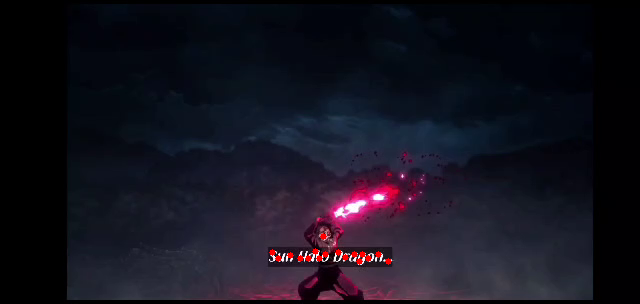

Dense Optical Flow
Flow Vectors: 903
Average Motion: 0.0084


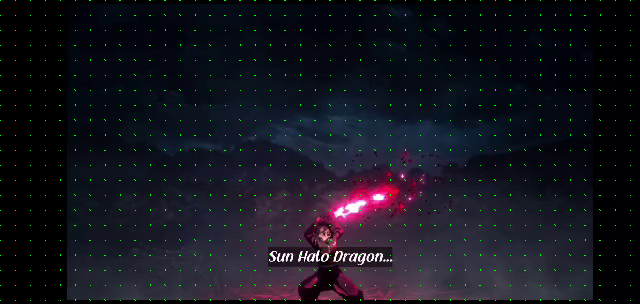

In [12]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

video_name = "video1.mp4"

cap = cv2.VideoCapture(video_name)

ret1, frame1 = cap.read()
ret2, frame2 = cap.read()

cap.release()

if not ret1 or not ret2:
    print("Could not read two frames from the video.")
else:
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    points = cv2.goodFeaturesToTrack(
        gray1,
        maxCorners=100,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    new_points, status, error = cv2.calcOpticalFlowPyrLK(
        gray1,
        gray2,
        points,
        None
    )

    good_old = points[status == 1]
    good_new = new_points[status == 1]

    sparse_output = frame2.copy()

    sparse_magnitudes = []

    for old, new in zip(good_old, good_new):
        x1, y1 = old.ravel()
        x2, y2 = new.ravel()

        dx = x2 - x1
        dy = y2 - y1

        magnitude = np.sqrt(dx**2 + dy**2)
        sparse_magnitudes.append(magnitude)

        cv2.arrowedLine(
            sparse_output,
            (int(x1), int(y1)),
            (int(x2), int(y2)),
            (0, 255, 0),
            2
        )

        cv2.circle(
            sparse_output,
            (int(x2), int(y2)),
            3,
            (0, 0, 255),
            -1
        )

    flow = cv2.calcOpticalFlowFarneback(
        gray1,
        gray2,
        None,
        0.5,
        3,
        15,
        3,
        5,
        1.2,
        0
    )

    dense_output = frame2.copy()

    dense_magnitudes = []

    step = 15

    for y in range(0, gray1.shape[0], step):
        for x in range(0, gray1.shape[1], step):

            fx, fy = flow[y, x]

            magnitude = np.sqrt(fx**2 + fy**2)
            dense_magnitudes.append(magnitude)

            cv2.arrowedLine(
                dense_output,
                (x, y),
                (int(x + fx), int(y + fy)),
                (0, 255, 0),
                1
            )

    print("Sparse Optical Flow")
    print("Tracked Points:", len(good_new))
    print("Average Motion:", round(np.mean(sparse_magnitudes), 4))
    cv2_imshow(sparse_output)

    print("Dense Optical Flow")
    print("Flow Vectors:", len(dense_magnitudes))
    print("Average Motion:", round(np.mean(dense_magnitudes), 4))
    cv2_imshow(dense_output)

11.Detection Speed vs Accuracy: Viola-Jones vs YOLO.

Saving image1.jpg to image1 (2).jpg

image 1/1 /content/image1 (2).jpg: 640x640 1 skateboard, 322.0ms
Speed: 6.7ms preprocess, 322.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
YuNet Detections: 0
YuNet Time: 0.0129 seconds
YuNet FPS: 77.47
YOLO Detections: 1
YOLO Time: 0.3665 seconds
YOLO FPS: 2.73
YuNet Result:


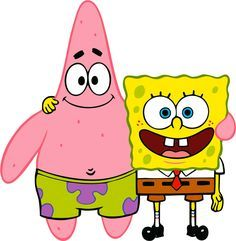

YOLO Result:


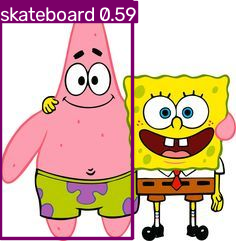

In [13]:
!pip -q install ultralytics

import cv2
import urllib.request
import time
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

model_url = "https://github.com/opencv/opencv_zoo/raw/main/models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
model_file = "face_detection_yunet_2023mar.onnx"

urllib.request.urlretrieve(model_url, model_file)

h, w = img.shape[:2]

detector = cv2.FaceDetectorYN.create(
    model_file,
    "",
    (w, h),
    0.8,
    0.3,
    5000
)

detector.setInputSize((w, h))

start = time.time()

_, faces = detector.detect(img)

yunet_time = time.time() - start

if faces is None:
    faces = []

yunet_output = img.copy()

for face in faces:
    x, y, width, height = face[:4].astype(int)

    cv2.rectangle(
        yunet_output,
        (x, y),
        (x + width, y + height),
        (0, 255, 0),
        2
    )

model = YOLO("yolo11n.pt")

start = time.time()

results = model(
    filename,
    conf=0.25
)

yolo_time = time.time() - start

yolo_output = results[0].plot()

yunet_fps = 1 / yunet_time if yunet_time > 0 else 0
yolo_fps = 1 / yolo_time if yolo_time > 0 else 0

print("YuNet Detections:", len(faces))
print("YuNet Time:", round(yunet_time, 4), "seconds")
print("YuNet FPS:", round(yunet_fps, 2))

print("YOLO Detections:", len(results[0].boxes))
print("YOLO Time:", round(yolo_time, 4), "seconds")
print("YOLO FPS:", round(yolo_fps, 2))

print("YuNet Result:")
cv2_imshow(yunet_output)

print("YOLO Result:")
cv2_imshow(yolo_output)

12.Confusion Matrix for Multi-Class Object Recognition.

Confusion Matrix:
[[3 1 0]
 [1 3 0]
 [0 1 3]]

Classification Report:
              precision    recall  f1-score   support

         cat       0.75      0.75      0.75         4
         dog       0.60      0.75      0.67         4
         car       1.00      0.75      0.86         4

    accuracy                           0.75        12
   macro avg       0.78      0.75      0.76        12
weighted avg       0.78      0.75      0.76        12



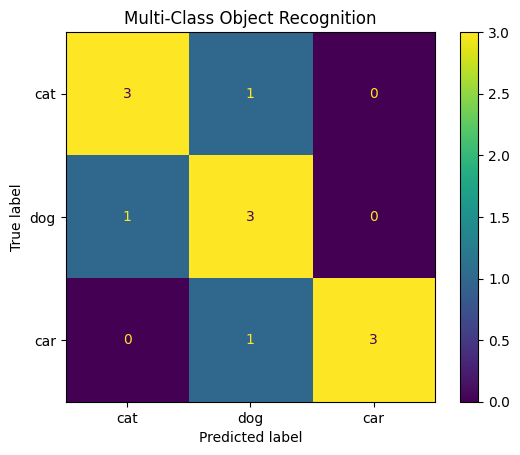

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = [
    "cat", "cat", "cat", "cat",
    "dog", "dog", "dog", "dog",
    "car", "car", "car", "car"
]

y_pred = [
    "cat", "cat", "dog", "cat",
    "dog", "dog", "cat", "dog",
    "car", "car", "dog", "car"
]

classes = ["cat", "dog", "car"]

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=classes
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        labels=classes
    )
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot()

plt.title("Multi-Class Object Recognition")
plt.show()